In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

# Model evaluation and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Interpretability libraries
import shap
from sklearn.inspection import permutation_importance
from sklearn.tree import export_text

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
## Loading the dataset into pandas dataframe
df=pd.read_csv('diabetes.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140.0,0
1,Female,54.0,0,0,No Info,27.32,6.6,80.0,0
2,Male,28.0,0,0,never,27.32,5.7,158.0,0
3,Female,36.0,0,0,current,23.45,5.0,155.0,0
4,Male,76.0,1,1,current,20.14,4.8,155.0,0
...,...,...,...,...,...,...,...,...,...
18564,Female,65.0,1,1,never,33.55,8.2,140.0,1
18565,Male,55.0,0,1,former,30.42,6.2,300.0,1
18566,Female,61.0,0,0,No Info,34.45,6.5,280.0,1
18567,Female,58.0,1,0,never,38.31,7.0,200.0,1


# Exploratory Data Analysis

Getting to know the data

Data Processing (Missing values)

Cross Tables and data visualisation

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18569 entries, 0 to 18568
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               18569 non-null  object 
 1   age                  18568 non-null  float64
 2   hypertension         18569 non-null  int64  
 3   heart_disease        18569 non-null  int64  
 4   smoking_history      18566 non-null  object 
 5   bmi                  18563 non-null  float64
 6   HbA1c_level          18566 non-null  float64
 7   blood_glucose_level  18568 non-null  float64
 8   diabetes             18569 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 1.3+ MB


In [4]:
df.isna().sum()


gender                 0
age                    1
hypertension           0
heart_disease          0
smoking_history        3
bmi                    6
HbA1c_level            3
blood_glucose_level    1
diabetes               0
dtype: int64

In [5]:

df.describe()  # Dispalying numerical data

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,18568.000000,18569.000000,18569.000000,18563.000000,18566.000000,18568.000000,18569.000000
mean,49.732749,0.146319,0.083957,29.233572,6.103032,160.738044,0.457752
std,21.758115,0.353435,0.277331,7.349860,1.275024,56.209179,0.498225
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,35.000000,0.000000,0.000000,25.640000,5.700000,130.000000,0.000000
50%,53.000000,0.000000,0.000000,27.320000,6.100000,155.000000,0.000000
75%,67.000000,0.000000,0.000000,32.500000,6.600000,200.000000,1.000000
max,80.000000,1.000000,1.000000,88.720000,9.000000,300.000000,1.000000


In [6]:
df.describe(include='O') # Printing categorical variables ie non-numerical variables

,gender,smoking_history
count,18569,18566
unique,3,6
top,Female,never
freq,10488,6941


In [7]:

## Encoding categorical variables
from sklearn.preprocessing import LabelEncoder
# Only encode if not already encoded
if 'smoking_history' in df.columns:
    df = pd.get_dummies(df, columns=['smoking_history', 'gender'], drop_first=False)
df.head()   

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Female,gender_Male,gender_Other
0,80.0,0,1,25.19,6.6,140.0,0,0,0,0,0,1,0,1,0,0
1,54.0,0,0,27.32,6.6,80.0,0,1,0,0,0,0,0,1,0,0
2,28.0,0,0,27.32,5.7,158.0,0,0,0,0,0,1,0,0,1,0
3,36.0,0,0,23.45,5.0,155.0,0,0,1,0,0,0,0,1,0,0
4,76.0,1,1,20.14,4.8,155.0,0,0,1,0,0,0,0,0,1,0


In [8]:
## dropping null values
df=df.dropna(how='any')

In [9]:
df.isna().sum()

age                            0
hypertension                   0
heart_disease                  0
bmi                            0
HbA1c_level                    0
blood_glucose_level            0
diabetes                       0
smoking_history_No Info        0
smoking_history_current        0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never          0
smoking_history_not current    0
gender_Female                  0
gender_Male                    0
gender_Other                   0
dtype: int64

In [10]:
#relationship between variables
corr=df.corr()
corr

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Female,gender_Male,gender_Other
age,1.000000,0.251297,0.251848,0.271310,0.283719,0.263204,0.473462,-0.272425,-0.008868,0.054066,0.216083,0.055443,0.053219,-0.007380,0.007931,-0.021463
hypertension,0.251297,1.000000,0.103452,0.163416,0.159226,0.140280,0.258370,-0.133455,0.008800,0.018929,0.080287,0.051190,0.005140,-0.017501,0.017637,-0.005265
heart_disease,0.251848,0.103452,1.000000,0.054136,0.133861,0.119066,0.215596,-0.061911,0.007565,0.055984,0.107549,-0.047071,0.000884,-0.095400,0.095503,-0.003848
bmi,0.271310,0.163416,0.054136,1.000000,0.200445,0.189354,0.344575,-0.210114,0.036999,0.030657,0.101274,0.072946,0.027487,0.023901,-0.023463,-0.017128
HbA1c_level,0.283719,0.159226,0.133861,0.200445,1.000000,0.324214,0.599393,-0.138723,0.027675,0.024392,0.087598,0.025571,0.026133,-0.048972,0.049102,-0.005010
blood_glucose_level,0.263204,0.140280,0.119066,0.189354,0.324214,1.000000,0.545401,-0.115813,0.031811,0.010118,0.080039,0.015247,0.022325,-0.038943,0.038991,-0.001824
diabetes,0.473462,0.258370,0.215596,0.344575,0.599393,0.545401,1.000000,-0.217859,0.032970,0.041949,0.151987,0.037811,0.036004,-0.074057,0.074360,-0.011678
smoking_history_No Info,-0.272425,-0.133455,-0.061911,-0.210114,-0.138723,-0.115813,-0.217859,1.000000,-0.206864,-0.136008,-0.240600,-0.478559,-0.171432,-0.027481,0.027441,0.001595
smoking_history_current,-0.008868,0.008800,0.007565,0.036999,0.027675,0.031811,0.032970,-0.206864,1.000000,-0.073368,-0.129789,-0.258153,-0.092477,-0.030802,0.030912,-0.004248
smoking_history_ever,0.054066,0.018929,0.055984,0.030657,0.024392,0.010118,0.041949,-0.136008,-0.073368,1.000000,-0.085333,-0.169729,-0.060801,-0.030249,0.030322,-0.002793


Text(0, 0.5, 'Count')

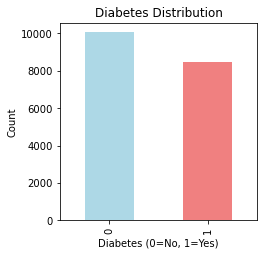

In [11]:
# Visualize class distribution
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
df['diabetes'].value_counts().plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Diabetes Distribution')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('Count')

In [12]:
from sklearn.utils import resample
majority_class = df[df.diabetes == 0]
minority_class = df[df.diabetes == 1]


print("Majority class size:", len(majority_class))
print("Minority class size:", len(minority_class))



Majority class size: 10067
Minority class size: 8491


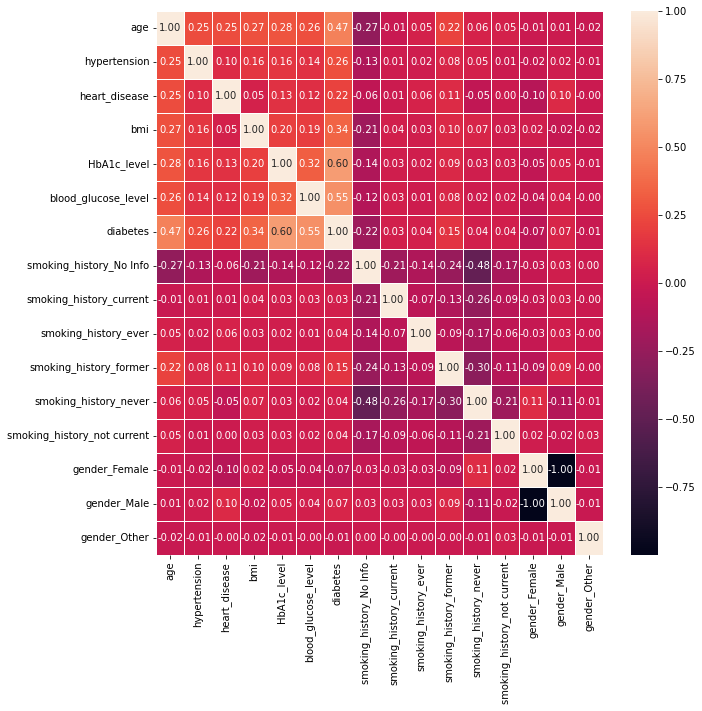

In [13]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, linewidth=0.5,fmt='0.2f')
plt.show()

 # Feature Engineering

 Splitting the data into features and target variables

In [14]:

# ## Splitting the data into features and target variable
# X = df_upsampled.drop('diabetes', axis=1)
# y = df_upsampled['diabetes']

# print("Feature matrix shape:", X.shape)
# print("Target vector shape:", y.shape)


## Splitting the data into features and target variable
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (18558, 15)
Target vector shape: (18558,)


In [15]:
# Split the data (with stratification to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Completes set: {X.shape[0]} samples")
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")




 Completes set: 18558 samples

Train set: 14846 samples
Test set: 3712 samples


In [16]:
# Feature Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model development and training

In [17]:
# Initializing models and handling class imbalance using weighted averaging approach
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=3),
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'SVM': SVC(class_weight='balanced', random_state=42, probability=True, kernel='rbf')
}

# Training individual models and store results
individual_models = {}
individual_predictions = {}
individual_probabilities = {}

print("Training individual models...")
print("="*50)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Using scaled data for LR and SVM and  original data for RF
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)
        test_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        test_proba = model.predict_proba(X_test)[:, 1]
    
    # Store model and predictions
    individual_models[name] = model
    individual_predictions[name] = test_pred
    individual_probabilities[name] = test_proba
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_precision = precision_score(y_test, test_pred, zero_division=0)
    test_recall = recall_score(y_test, test_pred, zero_division=0)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)
    
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)
    print(f"Confusion Matrix:\n{cm}")

print("\nIndividual model training completed!")

Training individual models...

Training Random Forest...
Train Accuracy: 0.9002
Test Accuracy: 0.8952
Test Precision: 0.9033
Test Recall: 0.8634
Test F1-Score: 0.8829
Confusion Matrix:
[[1857  157]
 [ 232 1466]]

Training Logistic Regression...
Train Accuracy: 0.8845
Test Accuracy: 0.8869
Test Precision: 0.8702
Test Recall: 0.8846
Test F1-Score: 0.8773
Confusion Matrix:
[[1790  224]
 [ 196 1502]]

Training SVM...
Train Accuracy: 0.8918
Test Accuracy: 0.8909
Test Precision: 0.8709
Test Recall: 0.8940
Test F1-Score: 0.8823
Confusion Matrix:
[[1789  225]
 [ 180 1518]]

Individual model training completed!


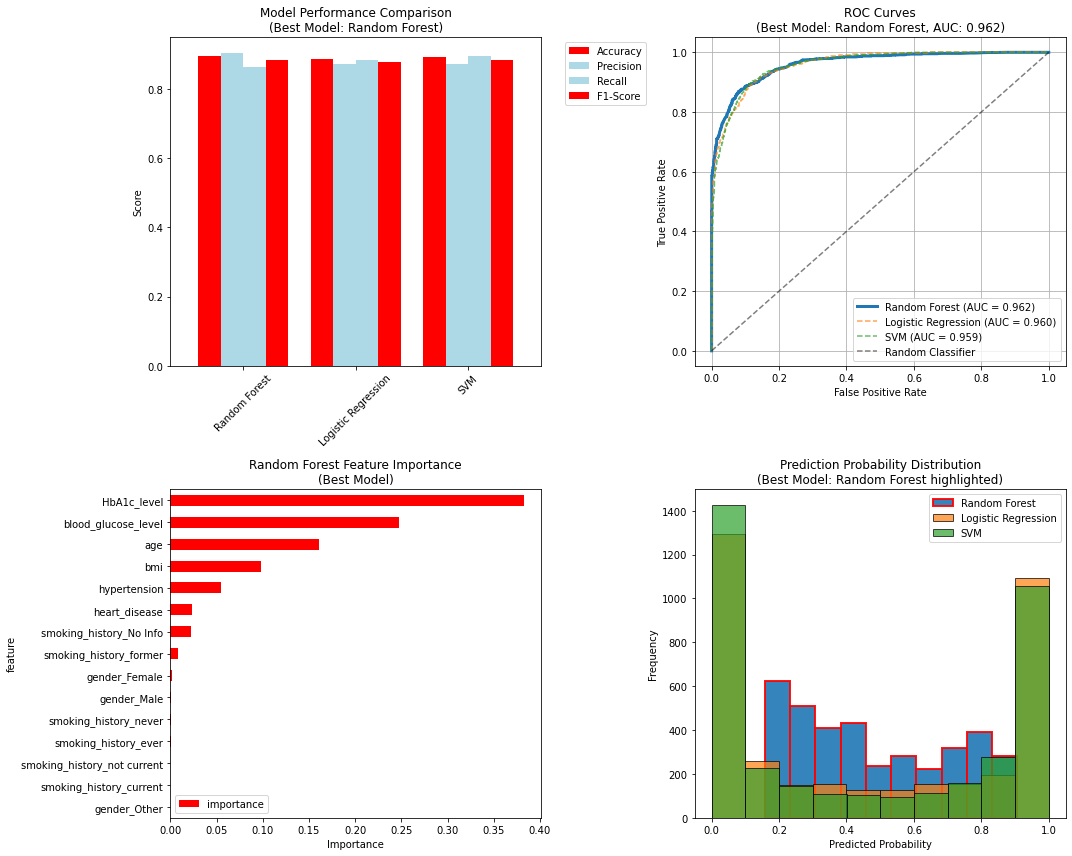


Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score
Random Forest          0.8952     0.9033  0.8634    0.8829
Logistic Regression    0.8869     0.8702  0.8846    0.8773
SVM                    0.8909     0.8709  0.8940    0.8823

Best Model: Random Forest
Average Score: 0.8862

Detailed Performance for Best Model (Random Forest):
----------------------------------------
Accuracy: 0.8952
Precision: 0.9033
Recall: 0.8634
F1-Score: 0.8829


In [18]:
    
# Create performance comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Performance Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(individual_models.keys())
performance_data = []

# Find best model for each metric
best_models = {}
for name in model_names:
    if name in ['Logistic Regression', 'SVM']:
        test_pred = individual_models[name].predict(X_test_scaled)
    else:
        test_pred = individual_models[name].predict(X_test)
    accuracy = accuracy_score(y_test, test_pred)
    precision = precision_score(y_test, test_pred, zero_division=0)
    recall = recall_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)
    performance_data.append([accuracy, precision, recall, f1])

performance_df = pd.DataFrame(performance_data, columns=metrics, index=model_names)

# Find best model (highest average score across all metrics)
performance_df['Average_Score'] = performance_df.mean(axis=1)
best_model_name = performance_df['Average_Score'].idxmax()
best_model_avg_score = performance_df.loc[best_model_name, 'Average_Score']
performance_df = performance_df.drop('Average_Score', axis=1)  # Remove average column for plotting

# Bar plot of performance metrics with best model highlighted
ax1 = axes[0, 0]
colors = ['lightblue' if name != best_model_name else 'red' for name in model_names]
performance_df.plot(kind='bar', ax=ax1, width=0.8, color=colors)
ax1.set_title(f'Model Performance Comparison\n(Best Model: {best_model_name})')
ax1.set_ylabel('Score')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_xticklabels(model_names, rotation=45)

# 2. ROC Curves with best model highlighted
ax2 = axes[0, 1]
best_auc = 0
best_model_roc = None

for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, individual_probabilities[name])
    auc_score = roc_auc_score(y_test, individual_probabilities[name])
    
    # Track best AUC score
    if auc_score > best_auc:
        best_auc = auc_score
        best_model_roc = name
    
    linewidth = 3 if name == best_model_name else 1.5
    linestyle = '-' if name == best_model_name else '--'
    alpha = 1.0 if name == best_model_name else 0.7
    
    ax2.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', 
             linewidth=linewidth, linestyle=linestyle, alpha=alpha)

ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title(f'ROC Curves\n(Best Model: {best_model_name}, AUC: {best_auc:.3f})')
ax2.legend()
ax2.grid(True)

# 3. Feature Importance (Random Forest)
ax3 = axes[1, 0]
rf_importance = individual_models['Random Forest'].feature_importances_
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importance
}).sort_values('importance', ascending=True)

# Highlight if Random Forest is the best model
color = 'red' if 'Random Forest' == best_model_name else 'lightblue'
importance_df.plot(x='feature', y='importance', kind='barh', ax=ax3, color=color)
ax3.set_title(f'Random Forest Feature Importance\n({"Best Model" if "Random Forest" == best_model_name else "Not Best Model"})')
ax3.set_xlabel('Importance')

# 4. Prediction Probabilities Distribution with best model highlighted
ax4 = axes[1, 1]
for name in model_names:
    alpha = 0.7 if name != best_model_name else 0.9
    edgecolor = 'red' if name == best_model_name else 'black'
    linewidth = 2 if name == best_model_name else 1
    ax4.hist(individual_probabilities[name], alpha=alpha, label=name, bins=10, 
             edgecolor=edgecolor, linewidth=linewidth)

ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title(f'Prediction Probability Distribution\n(Best Model: {best_model_name} highlighted)')
ax4.legend()

plt.tight_layout()
plt.show()

# Print performance summary with best model highlighted
print("\nModel Performance Summary:")
print("=" * 50)
print(performance_df.round(4))

print(f"\nBest Model: {best_model_name}")
print(f"Average Score: {best_model_avg_score:.4f}")
print("=" * 50)

# Print detailed metrics for the best model
print(f"\nDetailed Performance for Best Model ({best_model_name}):")
print("-" * 40)
for metric in metrics:
    score = performance_df.loc[best_model_name, metric]
    print(f"{metric}: {score:.4f}")

In [19]:
import numpy as np
import pandas as pd

# Use the best model (Random Forest) to make predictions
best_model = individual_models['Random Forest']

# Example input (replace with real values matching your feature order)
sample_data = pd.DataFrame([{
    'age': 80,
        'hypertension': 0,
        'heart_disease': 0,
        'bmi': 24.62,
        'HbA1c_level': 9,
        'blood_glucose_level': 160,
        'smoking_history_No Info': 0,
        'smoking_history_current': 0,
        'smoking_history_ever': 0,
        'smoking_history_former': 0,
        'smoking_history_never': 0,
        'smoking_history_not current': 1,
        'gender_Female': 0,
        'gender_Male': 1,
        'gender_Other': 0
}])

# Make prediction using Random Forest (uses original data, not scaled)
prediction = best_model.predict(sample_data)
probability = best_model.predict_proba(sample_data)[:, 1]

print("=" * 50)
print("PREDICTION USING BEST MODEL (RANDOM FOREST)")
print("=" * 50)
print(f"Predicted class: {prediction[0]}")
print(f"Probability of Diabetes: {probability[0]:.4f}")
print(f"Confidence: {probability[0] * 100:.2f}%")

# Interpret the prediction
if prediction[0] == 1:
    print("Prediction: DIABETES (Positive)")
else:
    print("Prediction: NO DIABETES (Negative)")

print("\nInput Features:")
print("=" * 30)
for feature, value in sample_data.iloc[0].items():
    print(f"{feature}: {value}")

PREDICTION USING BEST MODEL (RANDOM FOREST)
Predicted class: 1
Probability of Diabetes: 0.7369
Confidence: 73.69%
Prediction: DIABETES (Positive)

Input Features:
age: 80.0
hypertension: 0.0
heart_disease: 0.0
bmi: 24.62
HbA1c_level: 9.0
blood_glucose_level: 160.0
smoking_history_No Info: 0.0
smoking_history_current: 0.0
smoking_history_ever: 0.0
smoking_history_former: 0.0
smoking_history_never: 0.0
smoking_history_not current: 1.0
gender_Female: 0.0
gender_Male: 1.0
gender_Other: 0.0


In [20]:


import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
import shap
from sklearn.inspection import permutation_importance






1. GLOBAL FEATURE IMPORTANCE
List of Features by Importance:
--------------------------------------------------
HbA1c_level: 0.3822
blood_glucose_level: 0.2472
age: 0.1604
bmi: 0.0978
hypertension: 0.0547
heart_disease: 0.0230
smoking_history_No Info: 0.0222
smoking_history_former: 0.0087
gender_Female: 0.0018
gender_Male: 0.0010
smoking_history_never: 0.0003
smoking_history_ever: 0.0003
smoking_history_not current: 0.0001
smoking_history_current: 0.0001
gender_Other: 0.0000


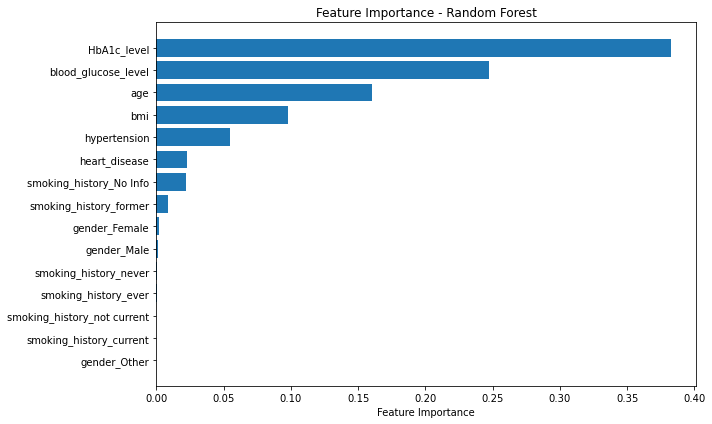

In [21]:
print("\n" + "="*60)
print("1. GLOBAL FEATURE IMPORTANCE")
print("="*60)

# Built-in Feature Importance
feature_importance = best_model.feature_importances_
feature_names = sample_data.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("List of Features by Importance:")
print("-" * 50)
for i, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


3. LIME EXPLANATION
Intercept 0.5882499401807274
Prediction_local [0.72162369]
Right: 0.73694672446292
LIME Explanation:
--------------------------------------------------


<Figure size 720x432 with 0 Axes>

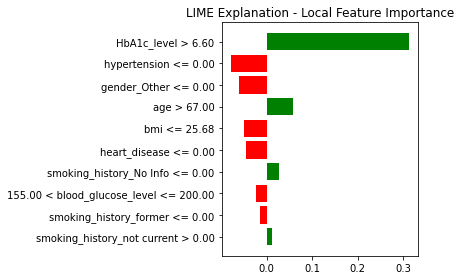


LIME Text Explanation:
------------------------------
HbA1c_level > 6.60: 0.3122
hypertension <= 0.00: -0.0793
gender_Other <= 0.00: -0.0616
age > 67.00: 0.0576
bmi <= 25.68: -0.0504
heart_disease <= 0.00: -0.0456
smoking_history_No Info <= 0.00: 0.0268
155.00 < blood_glucose_level <= 200.00: -0.0234
smoking_history_former <= 0.00: -0.0137
smoking_history_not current > 0.00: 0.0107


In [22]:

print("\n" + "="*60)
print("3. LIME EXPLANATION")
print("="*60)

# You'll need your training data for LIME
# Assuming you have X_train from your original training
# If not, you might need to recreate or load it

# Create LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values if 'X_train' in locals() else sample_data.values,  # Use available data
    feature_names=feature_names,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification',
    verbose=True,
    random_state=42
)

# Explain the instance
exp = explainer_lime.explain_instance(
    sample_data.iloc[0].values, 
    best_model.predict_proba, 
    num_features=10
)

print("LIME Explanation:")
print("-" * 50)

# Show in console
exp.show_in_notebook(show_table=True)

# Plot explanation
plt.figure(figsize=(10, 6))
exp.as_pyplot_figure()
plt.title('LIME Explanation - Local Feature Importance')
plt.tight_layout()
plt.show()

# Print explanation in text format
print("\nLIME Text Explanation:")
print("-" * 30)
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")


2. SHAP EXPLANATION


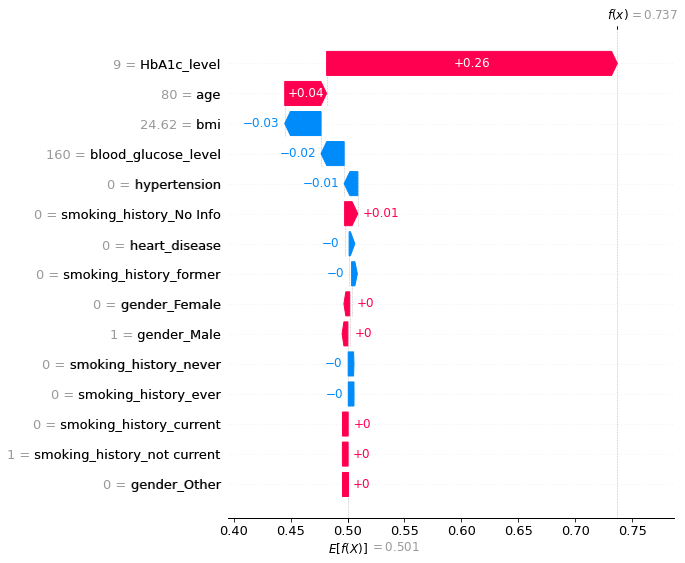

In [23]:
print("\n" + "="*60)
print("2. SHAP EXPLANATION")
print("="*60)

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(sample_data)
shap_values_all = explainer(sample_data)
shap.plots.waterfall(shap_values_all[0, :, 1], max_display=20)
plt.show()

In [24]:
import pickle
# Create a dictionary to hold the model and interpretability data
model = best_model

# Save to a pickle file
with open('rf_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved to 'rf_model.pkl'")

Model saved to 'rf_model.pkl'
